## Final Project: One Anomaly, Defended

Team members:
- Isidora Riquelme Rivera
- Benjamín Soto Henríquez

GitHub repository: [https://github.com/bsotoh/Entrega_Final_Preparacion_y_Analisis_de_Datos.git]

Video: [https://drive.google.com/drive/folders/1Yx8OOeltqYoTGw8mzfFK8NHPNZlqJ_kD?usp=sharing]

### The Anomaly:

San Pedro is the comuna that surprised us the most. In the Negative Binomial ENO model, it had the highest positive Pearson residual. The model expected about 346.81 ENO cases, but the observed value was 731. In other words, San Pedro reported around 384 more cases than expected, even after considering population size and the variables included in the model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

data_dir = Path("../Datos/processed")
figs_dir = Path("../figs")
figs_dir.mkdir(parents=True, exist_ok=True)

residuals = pd.read_csv(data_dir / "eno_nb_residuals.csv")
analytical_table = pd.read_csv(data_dir / "analytical_table.csv")

In [2]:
san_pedro = residuals[
    residuals["nombre_comuna"].str.lower().eq("san pedro")
].copy()

cols = [
    "codigo_comuna",
    "nombre_comuna",
    "eno_total",
    "predicted_eno_count",
    "pearson_residual"
]

san_pedro_summary = san_pedro[cols].copy()
san_pedro_summary["difference_observed_predicted"] = (
    san_pedro_summary["eno_total"] -
    san_pedro_summary["predicted_eno_count"]
)

san_pedro_summary

,codigo_comuna,nombre_comuna,eno_total,predicted_eno_count,pearson_residual,difference_observed_predicted
26,13505,San Pedro,731,346.809897,2.742378,384.190103


This table shows the main number behind the anomaly. San Pedro is not only a comuna with many ENO cases. What matters here is the gap between what we observed and what the model expected.

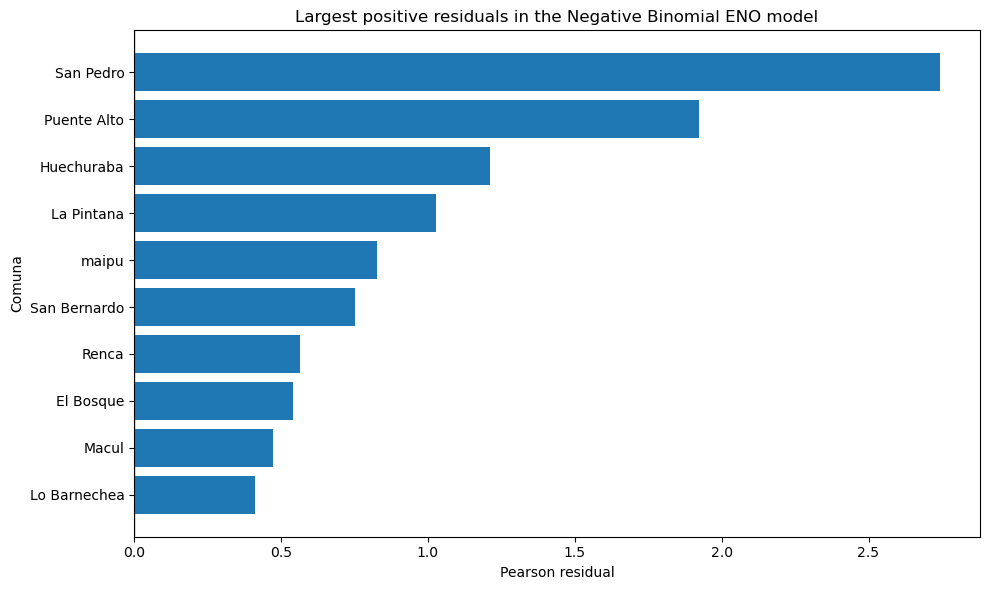

In [3]:
plot_df = (
    residuals[
        [
            "nombre_comuna",
            "eno_total",
            "predicted_eno_count",
            "pearson_residual"
        ]
    ]
    .sort_values("pearson_residual", ascending=False)
    .head(10)
    .copy()
)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["nombre_comuna"], plot_df["pearson_residual"])
plt.gca().invert_yaxis()
plt.axvline(0, linewidth=1)
plt.xlabel("Pearson residual")
plt.ylabel("Comuna")
plt.title("Largest positive residuals in the Negative Binomial ENO model")
plt.tight_layout()

plt.savefig(figs_dir / "headline.png", dpi=300, bbox_inches="tight")
plt.show()

The figure makes the anomaly easier to see. San Pedro appears at the top because it has the largest positive residual among the communes. This means that, compared with the model prediction, San Pedro reported many more ENO cases than expected.

### Alternative Explanation Check 1:

A first possibility is that San Pedro stands out only because of its population size. To check this, we compare the observed ENO cases with the cases predicted by the model. Since the model already considers population size, San Pedro should not remain so far from the prediction if population were the only reason.

In [4]:
population_check = (
    residuals[
        [
            "codigo_comuna",
            "nombre_comuna",
            "pop_total",
            "eno_total",
            "predicted_eno_count",
            "pearson_residual"
        ]
    ]
    .copy()
)

population_check["difference_observed_predicted"] = (
    population_check["eno_total"] -
    population_check["predicted_eno_count"]
)

population_check.sort_values("pearson_residual", ascending=False).head(10)

,codigo_comuna,nombre_comuna,pop_total,eno_total,predicted_eno_count,pearson_residual,difference_observed_predicted
26,13505,San Pedro,11108,731,346.809897,2.742378,384.190103
17,13201,Puente Alto,564477,4334,2446.549840,1.924476,1887.450160
2,13107,Huechuraba,101808,832,559.088627,1.212482,272.911373
7,13112,La Pintana,175421,1507,1067.332001,1.025897,439.667999
11,13119,maipu,500600,3316,2491.506201,0.825518,824.493799
20,13401,San Bernardo,306371,2172,1668.497430,0.752332,503.502570
15,13128,Renca,143622,1064,866.915579,0.565799,197.084421
1,13105,El Bosque,155257,1212,995.536758,0.541395,216.463242
10,13118,Macul,123800,890,747.851228,0.472790,142.148772
8,13115,Lo Barnechea,112620,630,540.323660,0.412169,89.676340


San Pedro still appears as the highest positive residual after this comparison. This suggests that the result is not explained only by population size. The number of observed cases is much higher than what the model expected for a comuna with San Pedro's population and general profile.

### Alternative Explanation Check 2:

Another possible explanation is that San Pedro looks unusual because it has very different values in the variables used by the model. To check this, we compare San Pedro with the general distribution of the communes in variables such as foreign population, schooling gap, employment gap, and lack of internet access.

In [5]:
covariates = [
    "pct_foreign",
    "schooling_gap",
    "employment_gap",
    "pct_no_internet"
]

covariate_check = residuals[
    ["nombre_comuna"] + covariates + [
        "eno_total",
        "predicted_eno_count",
        "pearson_residual"
    ]
].copy()

summary_covariates = covariate_check[covariates].describe().T

san_pedro_covariates = covariate_check[
    covariate_check["nombre_comuna"].str.lower().eq("san pedro")
]

display(summary_covariates)
display(san_pedro_covariates)

,count,mean,std,min,25%,50%,75%,max
pct_foreign,32.0,9.949481,8.534510,1.520991,5.227944,7.955127,11.340794,44.387437
schooling_gap,32.0,-0.798271,0.476294,-1.630000,-1.153994,-0.817899,-0.407500,0.075178
employment_gap,32.0,-11.784707,1.896654,-15.450000,-12.882811,-12.009355,-10.275000,-8.120000
pct_no_internet,32.0,31.319841,11.469136,15.539853,24.350669,30.017066,34.756238,78.468900


,nombre_comuna,pct_foreign,schooling_gap,employment_gap,pct_no_internet,eno_total,predicted_eno_count,pearson_residual
26,San Pedro,11.343176,0.075178,-15.42127,78.4689,731,346.809897,2.742378


This check shows that San Pedro is not a completely normal case in the variables used by the model. It has the highest percentage of people without fixed internet access, one of the largest employment gaps, and the highest schooling gap among the communes. Still, the model already considered these variables and predicted about 346.81 ENO cases, while the observed value was 731. So, these factors may help explain part of the difference, but they do not explain the whole anomaly.

### Conclusion:

San Pedro is the clearest anomaly in our Negative Binomial ENO model. The model predicted about 346.81 ENO cases, but the observed value was 731, leaving a gap of about 384 cases. The checks suggest that this difference is not only a population-size issue. We cannot claim a causal explanation from this notebook alone, but the result is strong enough to justify a closer review by disease type, time period, and local reporting conditions.